# What the RNN learns from

For every link and every hour of three networks' records, `build.py` stores:

- **inputs**: 60 one-minute values of *excess loss* (total loss above a causal 24-hour baseline)
  and four hourly summaries, plus the link's frequency, length, polarization and ITU-R
  coefficients (`core.cml.rnn.features`, `metadata`);
- **references**: the radar averaged along the link's path, the gauges within 3 km of it, and
  their mean - the *target* the RNN is trained on;
- **power-law estimates**: four methods of `core.cml` on the same links and hours.

Built by `python src/run.py build` into `dataset/open_datasets/_cml_rnn/` (not tracked).

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cml_rnn.train import NetData

In [2]:
datas = {n: NetData.load(n) for n in ("openmrg", "openrainer", "openmesh")}
rows = []
for n, d in datas.items():
    t = pd.DatetimeIndex(d.ds.time.values)
    rows.append({"network": n, "links": d.X.shape[0], "hours": d.X.shape[1],
                 "from": f"{t[0]:%Y-%m-%d}", "to": f"{t[-1]:%Y-%m-%d}",
                 "train h": int((d.part == 0).sum()), "validation h": int((d.part == 1).sum()),
                 "test h": int((d.part == 2).sum()),
                 "wet link-hours (target >= 0.1 mm)": int((d.y >= 0.1).sum())})
pd.DataFrame(rows)

,network,links,hours,from,to,train h,validation h,test h,wet link-hours (target >= 0.1 mm)
0,openmrg,716,2208,2015-06-01,2015-09-01,833,412,963,158048
1,openrainer,288,10272,2021-05-01,2022-12-01,4503,2512,3257,214742
2,openmesh,39,5832,2023-11-01,2024-07-01,2749,1182,1901,21673


## The split

ISO weeks cycle train, train, validation, test, so every season is in every part. The ten
largest storms of each network (the ones `multisensor_maps` maps) are always test.

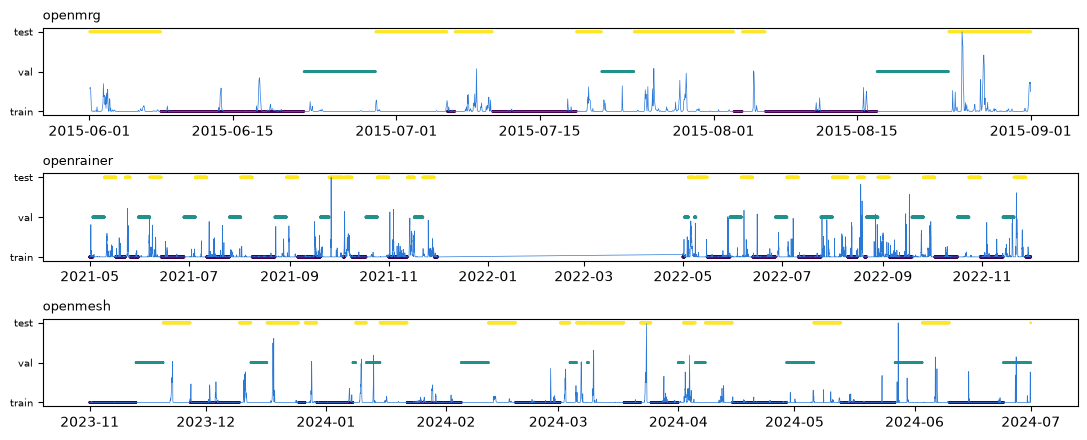

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 4.5))
for ax, (n, d) in zip(axes, datas.items()):
    t = pd.DatetimeIndex(d.ds.time.values)
    ax.scatter(t, d.part, c=d.part, cmap="viridis", s=1)
    ax.plot(t, np.nanmean(d.y, axis=0) / np.nanmax(np.nanmean(d.y, axis=0)) * 2, color="#2a78d6", lw=0.5)
    ax.set_yticks([0, 1, 2], ["train", "val", "test"], fontsize=7)
    ax.set_title(n, fontsize=9, loc="left")
fig.tight_layout()

## One link, one storm

The excess loss rises with rain; the references are the radar along the path and the gauges
near it. Where they disagree, the target is their mean.

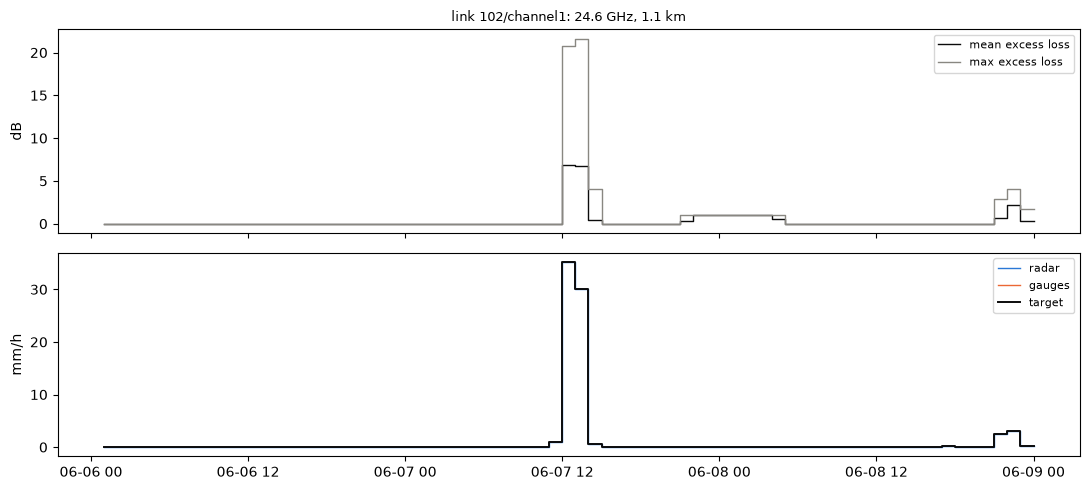

In [4]:
d = datas["openrainer"]
test = d.part == 2
li = int(np.nanargmax(np.nansum(np.where(test, d.y, np.nan), axis=1)))
k = int(np.nanargmax(np.where(test, np.nan_to_num(d.y[li]), -1)))
sl = slice(k - 36, k + 36)
t = pd.DatetimeIndex(d.ds.time.values[sl])
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].step(t, d.X[li, sl, 61], where="pre", color="#0b0b0b", lw=1, label="mean excess loss")
axes[0].step(t, d.X[li, sl, 62], where="pre", color="#898781", lw=1, label="max excess loss")
axes[0].set_ylabel("dB"); axes[0].legend(fontsize=8)
for v, c in (("radar", "#2a78d6"), ("gauges", "#eb6834"), ("target", "#0b0b0b")):
    axes[1].step(t, d.ds[v].values[li, sl], where="pre", color=c, lw=1.4 if v == "target" else 1, label=v)
axes[1].set_ylabel("mm/h"); axes[1].legend(fontsize=8)
axes[0].set_title(f"link {d.ds.link.values[li]}: {float(d.ds.frequency[li]):.1f} GHz, {float(d.ds.length[li]):.1f} km",
                  fontsize=9)
fig.tight_layout()